## TASK -1

### 1. Data Access & Familiarization  :


In [1]:
import numpy as np
import pandas as pd

In [2]:
df= pd.read_excel("ApexPlanet_DataAnalytics_Dataset.xlsx")

In [3]:
df.shape

(1000, 12)

In [4]:
# checking the first 5 rows
df.head()

,Order_ID,Order_Date,Customer_ID,Customer_Name,Age,Gender,City,Product,Category,Quantity,Unit_Price,Total_Sales
0,ORD100002,2025-02-25,CUST5529,Customer_227,30.0,Female,Bengaluru,Rice,Grocery,7,2829.77,19808.39
1,ORD100003,2025-10-14,CUST3127,Customer_182,63.0,Male,Bengaluru,Book,Education,5,27906.16,139530.80
2,ORD100004,2025-05-13,CUST8887,Customer_487,62.0,Female,Bengaluru,Book,Education,8,37491.06,299928.48
3,ORD100005,2025-12-02,CUST2515,Customer_470,65.0,Female,Kolkata,Mobile,Electronics,9,28541.36,256872.24
4,ORD100006,2025-11-20,CUST4796,Customer_380,44.0,Male,Bengaluru,Rice,Grocery,10,14036.59,140365.90


In [5]:
# data information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order_ID       1000 non-null   object 
 1   Order_Date     1000 non-null   object 
 2   Customer_ID    1000 non-null   object 
 3   Customer_Name  1000 non-null   object 
 4   Age            980 non-null    float64
 5   Gender         1000 non-null   object 
 6   City           987 non-null    object 
 7   Product        1000 non-null   object 
 8   Category       1000 non-null   object 
 9   Quantity       1000 non-null   int64  
 10  Unit_Price     1000 non-null   float64
 11  Total_Sales    1000 non-null   float64
dtypes: float64(3), int64(1), object(8)
memory usage: 93.9+ KB


| Variable Name | Data Type | Description | Analytical Relevance |
| :--- | :--- | :--- | :--- |
| **`Order_ID`** | Object / String | Unique alphanumeric identifier for each order transaction | Transaction tracking . |
| **`Order_Date`** | Object / Date | Timestamp/date when the order was placed (Year 2025) | Seasonality, monthly patterns. |
| **`Customer_ID`** | Object / String | Unique identifier assigned to each consumer | Customer retention and repeat purchase behavior. |
| **`Customer_Name`**| Object / String | Masked customer name (e.g., `Customer_227`) | Anonymized reference identifier. |
| **`Age`** | Float64 / Numeric | Age of the purchasing customer in years (Range: 18 - 65) | Demographic segmentation and age cohort analysis. |
| **`Gender`** | Object / Binary | Gender classification of the customer (`Male`, `Female`) | Gender preference and category affinity evaluation. |
| **`City`** | Object / Nominal | Fulfillment delivery destination city | Geographic distribution and regional demand mapping. |
| **`Product`** | Object / Nominal | Product purchased (Mobile, Book, Laptop, Chair, Shoes, Rice) | product volume, and basket composition. |
| **`Category`** | Object / Nominal | Commercial vertical (Electronics, Education, Furniture, Fashion, Grocery) | Strategic merchandise planning and inventory allocation. |
| **`Quantity`** | Int64 / Discrete | Number of units purchased in the order (Range: 1 - 10) | Order volume, bulk purchasing, and pricing elasticities. |
| **`Unit_Price`** | Float64 / Continuous| Price per single unit of the product in INR | Pricing tiers. |
| **`Total_Sales`** | Float64 / Continuous| Total monetary transaction value (`Quantity * Unit_Price`) | Primary target variable for predictive machine learning. |



### 2. Data Quality Assessment  :

In [6]:
# checking null values
df.isnull().sum()

Order_ID          0
Order_Date        0
Customer_ID       0
Customer_Name     0
Age              20
Gender            0
City             13
Product           0
Category          0
Quantity          0
Unit_Price        0
Total_Sales       0
dtype: int64

In [7]:
df[df['Order_ID'].duplicated()]

,Order_ID,Order_Date,Customer_ID,Customer_Name,Age,Gender,City,Product,Category,Quantity,Unit_Price,Total_Sales
118,ORD100050,2025-01-22,CUST3194,Customer_114,34.0,Male,Kolkata,Book,Education,2,25795.55,51591.10
238,ORD100050,2025-03-01,CUST8467,Customer_104,23.0,Male,Bengaluru,Book,Education,3,2860.83,8582.49
358,ORD100050,2025-02-11,CUST6467,Customer_181,24.0,Female,Pune,Rice,Grocery,7,45480.39,318362.73
478,ORD100050,2025-11-22,CUST8225,Customer_468,64.0,Male,Bengaluru,Rice,Grocery,8,38957.59,311660.72
598,ORD100050,2025-02-21,CUST8859,Customer_53,NaN,Male,NaN,Laptop,Electronics,7,20144.84,141013.88
718,ORD100050,2025-11-06,CUST7824,Customer_190,31.0,Female,Mumbai,Rice,Grocery,4,42642.59,170570.36
838,ORD100050,2025-08-03,CUST5585,Customer_289,35.0,Male,Kolkata,Chair,Furniture,9,28747.47,258727.23
958,ORD100050,2025-02-09,CUST7188,Customer_89,62.0,Male,Bengaluru,Mobile,Electronics,1,34619.77,34619.77


In [8]:
df['Order_ID'].nunique()

992

##### OrderID contains duplicate values; however, they correspond to different transaction records and are not true duplicates. Since OrderID is an identifier and not a predictive feature, these records were retained without modification.

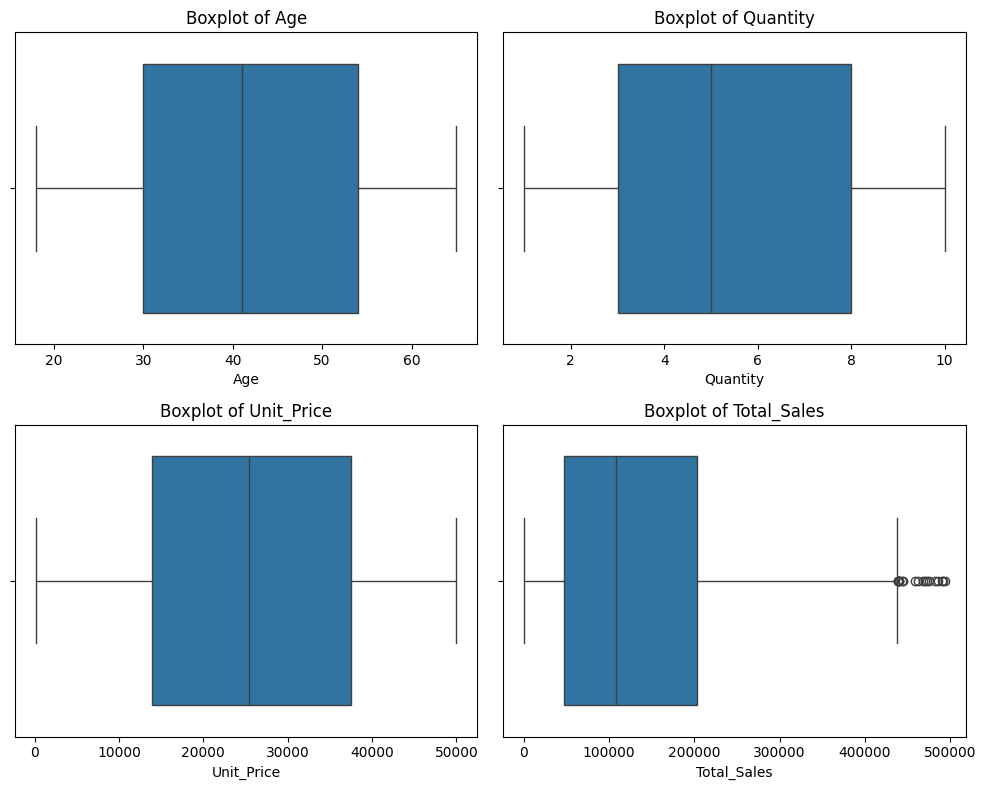

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
plot_num=1
plt.figure(figsize=(10,8))
for col in numerical_cols:
    plt.subplot(2,2,plot_num)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)
    plot_num +=1
plt.tight_layout()
plt.show()

In [10]:
q1 = df['Total_Sales'].quantile(0.25)
q3 = df['Total_Sales'].quantile(0.75)

IQR = q3-q1
lower_bound = q1 - 1.5*IQR
upper_bound = q3 + 1.5*IQR

outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

print(f"{col}: {len(outliers)} outliers")

Total_Sales: 19 outliers


### 3. Data Cleaning & Transformation :

#### Replacing Null Value

In [11]:
print(df['Age'].min())
print(df['Age'].max())

18.0
65.0


In [12]:
common_age = df['Age'].value_counts().idxmax()
common_age_count = df['Age'].value_counts().max()
print(common_age , common_age_count)

30.0 35


In [13]:
# Replace all the null value of age with median value
df['Age']= df['Age'].fillna(df['Age'].median()).astype(int)

In [14]:
# checking cities available in our dataset
df['City'].value_counts()

City
Patna        135
Kolkata      133
Mumbai       131
Hyderabad    125
Delhi        125
Bengaluru    122
Gaya         117
Pune          99
Name: count, dtype: int64

In [15]:
df['City'] = df['City'].fillna('Pune')

In [16]:
# Checking NUll values after replacing
df.isnull().sum()

Order_ID         0
Order_Date       0
Customer_ID      0
Customer_Name    0
Age              0
Gender           0
City             0
Product          0
Category         0
Quantity         0
Unit_Price       0
Total_Sales      0
dtype: int64

#### Sort the dataset in chronological order based on Order_Date

In [17]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

In [18]:
df.sort_values(by='Order_Date').reset_index(drop =True)

,Order_ID,Order_Date,Customer_ID,Customer_Name,Age,Gender,City,Product,Category,Quantity,Unit_Price,Total_Sales
0,ORD100593,2025-01-01,CUST1840,Customer_90,43,Female,Kolkata,Laptop,Electronics,2,11893.80,23787.60
1,ORD100811,2025-01-04,CUST6719,Customer_394,30,Female,Patna,Book,Education,3,15090.15,45270.45
2,ORD100747,2025-01-04,CUST9339,Customer_127,55,Male,Patna,Chair,Furniture,5,49147.41,245737.05
3,ORD100199,2025-01-04,CUST7187,Customer_149,38,Male,Patna,Mobile,Electronics,1,16633.85,16633.85
4,ORD100730,2025-01-05,CUST4553,Customer_489,44,Female,Kolkata,Chair,Furniture,5,33187.56,165937.80
...,...,...,...,...,...,...,...,...,...,...,...,...
995,ORD100307,2026-01-01,CUST1231,Customer_339,53,Male,Patna,Rice,Grocery,4,46771.94,187087.76
996,ORD100796,2026-01-01,CUST6845,Customer_385,57,Female,Mumbai,Shoes,Fashion,9,38573.17,347158.53
997,ORD100079,2026-01-01,CUST4706,Customer_34,62,Female,Delhi,Rice,Grocery,1,35862.34,35862.34
998,ORD100165,2026-01-01,CUST8010,Customer_187,41,Female,Hyderabad,Rice,Grocery,4,35300.11,141200.44


**The dataset was sorted chronologically using the Order_Date column to maintain the correct sequence of transactions. The index was then reset to generate a clean and continuous row numbering after sorting, improving data organization and ensuring consistency for time-based analysis and feature engineering.**